# Part C Dissertation - Modelling Networks with Complex Weights
## Empirical Spectral Gap Calculator
#### _(Candidate 1074092)_

In this notebook, we work with the empirical graphs for the Florida Bay food web and Motueka influence matrix. We calculate the spectral gap for varying $r$ and generate accompanying plots.

The first half of this notebook is dedicated to the drawing of diagrams representing the empirical graphs. The second half is where the calculations and accompanying plots are generated.

This notebook is set up to input the data from one network, and then create illustrations/run calculations/plot spectral gap and eigenvalues. We run this once for the Florida food web ("floridaFoodWeb.csv") and the Motueka influence matrix ("iMatrix_submatrix_manual.csv"). 

### Illustrations (full and nested cycle)

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy
import numpy as np
import pandas as pd
import operator

In [2]:
def ordered_cycle_layout(node_list):
    n = len(node_list)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    pos = {node: (np.cos(angle), np.sin(angle)) for node, angle in zip(node_list, angles)}
    return pos

def shelldraw_ordered(G, node_order):
    pos_cycle = ordered_cycle_layout(node_order)
    nx.draw(G, pos, with_labels=True, font_weight='bold', node_color='grey')
    plt.show()

In [3]:
df = pd.read_csv("floridaFoodWeb.csv", index_col=0)
#"floridaFoodWeb.csv" for Florida Food Web
#"iMatrix_submatrix_manual.csv" for Influence Matrix

G = nx.DiGraph()
for source in df.index:
    for target in df.columns:
        if source == target:
            continue
        weight = df.loc[source, target]
        if weight > 0:
            G.add_edge(source, target, weight=weight)
            
cycleList = sorted(nx.simple_cycles(G))
length = len(cycleList)
cLengList = np.zeros(length)

for i in range(0, length):
    cLengList[i] = len(cycleList[i])
longestCycle = cycleList[np.argmax(cLengList)]

C:\Users\rapha\AppData\Local\Temp\ipykernel_31916\3133837363.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


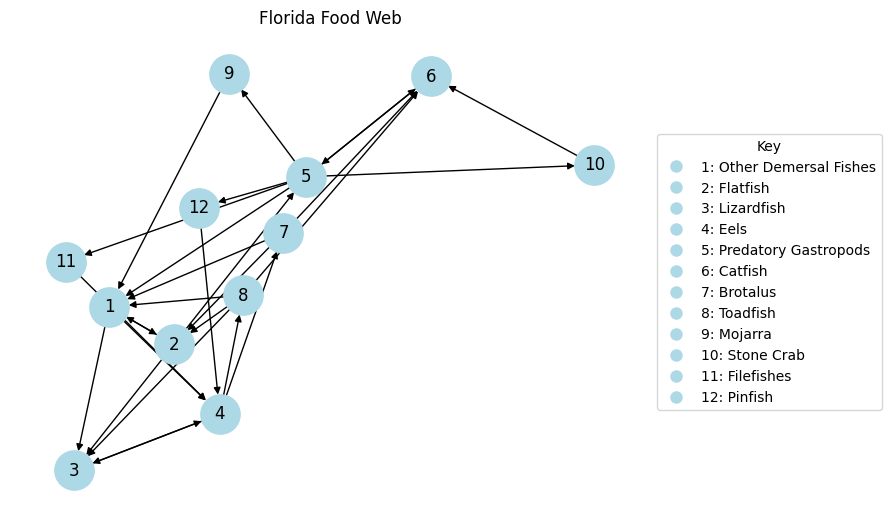

In [4]:
# Relabel nodes with numbers
mapping = {node: i for i, node in enumerate(G.nodes(), start=1)}
G_num = nx.relabel_nodes(G, mapping)

# Reverse mapping for legend
key_labels = {v: k for k, v in mapping.items()}

# Draw graph
pos = nx.spring_layout(G_num)
nx.draw(G_num, pos, with_labels=True, node_color="lightblue", node_size=800)

# Create legend handles (dummy markers)
handles = []
for num, name in key_labels.items():
    handle = Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='lightblue',
        markersize=10,
        label=f"{num}: {name}"
    )
    handles.append(handle)

# Add legend on the side
plt.legend(
    handles=handles,
    title="Key",
    loc="center left",
    bbox_to_anchor=(1, 0.5)  # push legend outside plot
)

plt.title("Florida Food Web")
plt.tight_layout()
plt.show()

In [5]:
G = nx.DiGraph()
for source in df.index:
    for target in df.columns:
        if source == target:
            continue
        weight = df.loc[source, target]
        if weight > 0:
            G.add_edge(source, target, weight=weight)
            
cycleList = sorted(nx.simple_cycles(G))
length = len(cycleList)
cLengList = np.zeros(length)

for i in range(0, length):
    cLengList[i] = len(cycleList[i])
longestCycle = cycleList[np.argmax(cLengList)]

In [6]:
cycle_nodes = list(longestCycle)  # your computed cycle
G_cycle = G.subgraph(longestCycle)
pos_cycle = ordered_cycle_layout(longestCycle)

def get_node_color(node_name):
    if node_name in cycle_set:
        return "lightblue"   # outer cycle
    else:
        return "orange"  # inner nodes

C:\Users\rapha\AppData\Local\Temp\ipykernel_31916\61088618.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


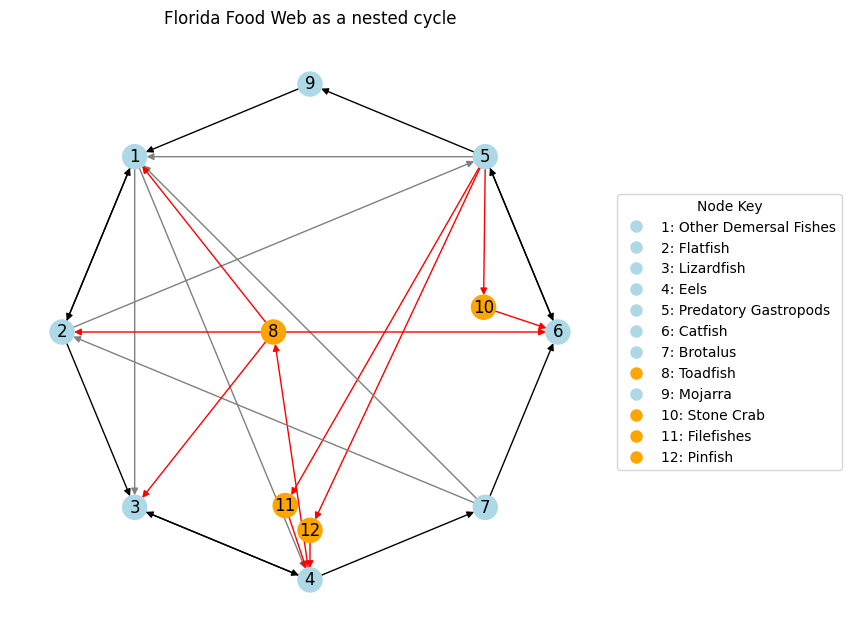

In [7]:
# Relabel nodes with numbers
mapping = {node: i for i, node in enumerate(G.nodes(), start=1)}
G_num = nx.relabel_nodes(G, mapping)

# Reverse mapping for legend
key_labels = {v: k for k, v in mapping.items()}

# Draw graph
cycle_nodes = list(longestCycle)  # your computed cycle
G_cycle = G.subgraph(longestCycle)
pos_cycle = ordered_cycle_layout(longestCycle)
#pos_cycle = nx.circular_layout(G_cycle, scale=2.0)  # outer ring

remaining_nodes = [n for n in G.nodes if n not in cycle_nodes]
G_inner = G.subgraph(remaining_nodes)

#pos_inner determiner
pos_inner = {}
epsilon = 0.1  # controls spacing
alpha = 0.7 # controls "pulling effect"

for i, n in enumerate(remaining_nodes):
    neighbors = [nbr for nbr in G.neighbors(n) if nbr in pos_cycle]
    
    if neighbors:
        x = sum(pos_cycle[v][0] for v in neighbors) / len(neighbors)
        y = sum(pos_cycle[v][1] for v in neighbors) / len(neighbors)
    else:
        x, y = 0, 0

    # Add deterministic offset (prevents overlap)
    angle = 2 * np.pi * i / len(remaining_nodes)
    dx = epsilon * np.cos(angle)
    dy = epsilon * np.sin(angle)

    pos_inner[n] = (alpha * x + dx, alpha * y + dy)

#pos of all
pos = {}
pos.update(pos_cycle)
pos.update(pos_inner)

# --- Set colours ---
cycle_set = set(cycle_nodes)
node_colors = [
    get_node_color(key_labels[n]) for n in G_num.nodes()
]
        
cycle_edges = set()
for i in range(len(cycle_nodes)):
    u = cycle_nodes[i]
    v = cycle_nodes[(i + 1) % len(cycle_nodes)]
    cycle_edges.add((u, v))
    cycle_edges.add((v, u))  # for undirected graph

edge_colors = []

for u_num, v_num in G_num.edges():
    u = key_labels[u_num]
    v = key_labels[v_num]

    if (u, v) in cycle_edges:
        edge_colors.append("black")
    elif u not in cycle_set or v not in cycle_set:
        edge_colors.append("red")
    else:
        edge_colors.append("gray")

# --- Set letters ---
#change numbers to letters
mapping = {node: i for i, node in enumerate(G.nodes(), start=1)}
G_num = nx.relabel_nodes(G, mapping)

# Update positions to numeric keys
pos_num = {mapping[node]: coords for node, coords in pos.items()}

# Reverse mapping for legend
key_labels = {v: k for k, v in mapping.items()}

# --- 3. DRAW GRAPH ---

plt.figure(figsize=(6, 6))

nx.draw(
    G_num,
    pos_num,
    with_labels=True,
    node_color=node_colors,
    edge_color=edge_colors,
    node_size=300,
)

# --- 4. LEGEND (KEY) ---

handles = []
for num, name in sorted(key_labels.items()):
    color = get_node_color(name)
    handles.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=color,
            markersize=10,
            label=f"{num}: {name}"
        )
    )

plt.legend(
    handles=handles,
    title="Node Key",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Florida Food Web as a nested cycle")
plt.tight_layout()
plt.show()

### Calculations

We run the calculations for $r \in \{2, 3, 4, 5, 6\}$ for our table of results, and then for $r$ varied continuously between those points so that we can plot the accompanying graphs.

In [8]:
def DiCycle(n):
    C_n = nx.cycle_graph(n, create_using=nx.DiGraph())
    C_n = nx.relabel_nodes(C_n, {0: n})
    return C_n

In [9]:
def symSpecGap(G):
    gLapN = nx.normalized_laplacian_matrix(G.to_undirected()).toarray()
    gLapEigs = np.linalg.eigvalsh(gLapN)
    return (gLapEigs[1]- gLapEigs[0])

In [10]:
def dirSpecGap(G):
    dLapN = nx.directed_laplacian_matrix(G)
    dLapEigs = np.linalg.eigvalsh(dLapN)
    return (dLapEigs[1] - dLapEigs[0])

In [11]:
def mLapN(M, theta):
    M = M.toarray()
    n = np.shape(M)[0]
    #defines unweighted symmetric matrix
    W_s = (M + M.T) / 2

    #directional info matrix
    A = M
    A[(M > 0) & (M.T == 0)] = 1
    A[(M == 0) & (M.T > 0)] = -1
        
    #T matrix
    T = np.exp(1j * theta * A)
    #L matrix
    L = -W_s * T
    np.fill_diagonal(L, np.sum(W_s, axis=1))

    #Normalisation step, sets L_N = D^(-1/2) * L * D^(-1/2)
    D = np.sum(W_s, axis=1)
    normD = 1 / np.sqrt(D)
    L_N = (normD[:, None] * L) * normD[None, :]
    
    return L_N

def eig_rValuesN(A, rValues):
    sims = len(rValues)
    n = np.shape(A)[0]
    eigArray = np.empty((sims, n + 1), dtype=float)
    #note that we essentially set q = theta/2π, so for varying r as before we have r = 1/q
    thetaValues = (2*np.pi)/np.array(rValues)
    
    for i in range (0, sims):
        L_N = mLapN(A, thetaValues[i])
        eigs = np.linalg.eigvalsh(L_N)
        eigArray[i, 0] = rValues[i]
        for j in range(0, n):
            eigArray[i, j + 1] = eigs[j]
    return eigArray

In [12]:
def maxDict(D):
    #return max(dictionary.iteritems(), key=operator.itemgetter(1))[0]
    return max(D, key=D.get)

In [13]:
def specGap_rValues(G, rValues):
    specGap = {}
    A = nx.adjacency_matrix(G)
    for r in rValues:
        eigArray = eig_rValuesN(A, [r])
        specGap[r] = eigArray[0, 2] - eigArray[0, 1]
    return specGap

In [14]:
def maxDict(D):
    #return max(dictionary.iteritems(), key=operator.itemgetter(1))[0]
    return max(D, key=D.get)

In [15]:
def specGapList(G, rValues):
    rLen = len(rValues)
    specGap = np.zeros(rLen)
    eig1 = np.zeros(rLen)
    eig2 = np.zeros(rLen)
    A = nx.adjacency_matrix(G)
    for i in range(0, rLen):
        r = rValues[i]
        eigArray = eig_rValuesN(A, [r])
        specGap[i] = eigArray[0, 2] - eigArray[0, 1]
        eig1[i] = eigArray[0, 1]
        eig2[i] = eigArray[0, 2]
    return specGap, eig1, eig2

In [16]:
C_n = DiCycle(len(longestCycle))
G_sub = G.subgraph(longestCycle)
G_full = G.copy()

symSG_Cn = symSpecGap(C_n)
symSG_Gsub = symSpecGap(G_sub)
symSG_Gfull = symSpecGap(G_full)
print(symSG_Cn, symSG_Gsub, symSG_Gfull)

dirSG_Cn = dirSpecGap(C_n)
dirSG_Gsub = dirSpecGap(G_sub)
dirSG_Gfull = dirSpecGap(G_full)
print(dirSG_Cn, dirSG_Gsub, dirSG_Gfull)

0.2928932188134522 0.571075919370174 0.49796610881293285
0.1464466094067263 0.2925372571425897 0.3031897762420377


In [17]:
rValues = [2, 3, 4, 5, 6, 7, 8]
specGap_Cn = specGap_rValues(C_n, rValues)
specGap_Gsub = specGap_rValues(G_sub, rValues)
specGap_Gfull = specGap_rValues(G_full, rValues)

In [18]:
for r in rValues:
    print(r, specGap_Gfull[r])

2 0.04270569904072585
3 0.17802816300889004
4 0.12981525678411843
5 0.11397663363136823
6 0.0224384242929781
7 0.06712907045029831
8 0.13708922502370507


In [19]:
sGMax_Cn = maxDict(specGap_Cn)
sGMax_Gsub = maxDict(specGap_Gsub)
sGMax_Gfull = maxDict(specGap_Gfull)

print(sGMax_Cn, sGMax_Gsub, sGMax_Gfull)
print(specGap_Cn[sGMax_Cn], specGap_Gsub[sGMax_Gsub], specGap_Gfull[sGMax_Gfull])
print(specGap_Cn[3], specGap_Gsub[3], specGap_Gfull[3])

8 2 3
0.2928932188134526 0.21520564667048572 0.17802816300889004
0.09990042250462955 0.16634180116997754 0.17802816300889004


In [20]:
rValues = [n / 100 for n in range(100, 700)]
specGap_Cn, eig1Cn, eig2Cn = specGapList(C_n, rValues)
specGap_Gsub, eig1Gsub, eig2Gsub = specGapList(G_sub, rValues)
specGap_Gfull, eig1Gfull, eig2Gfull = specGapList(G_full, rValues)

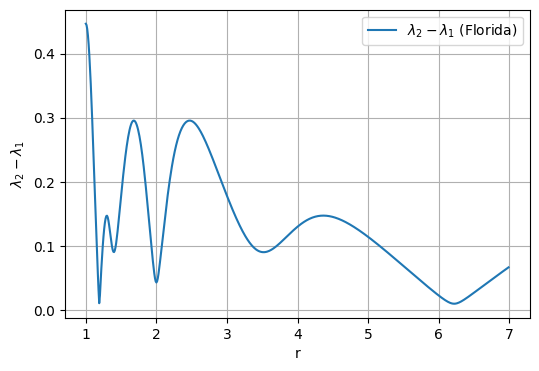

In [21]:
plt.figure(figsize=(6, 4))
#plt.plot(rValues, specGap_Cn, label=r"$C_n$")
plt.plot(rValues, specGap_Gfull, label=r"$\lambda_{2}-\lambda_{1}$ (Florida)") #$\lambda_{2}-\lambda_{1}$
#plt.plot(rValues, specGap_Gsub, label=r"$G_{sub}$")
plt.xlabel(f"r")
plt.ylabel("$\lambda_{2}-\lambda_{1}$")
#plt.title(r"$\lambda_{2}-\lambda_{1}$ for varying r (Florida)")
plt.legend()
plt.grid(True)
plt.legend()
plt.show()

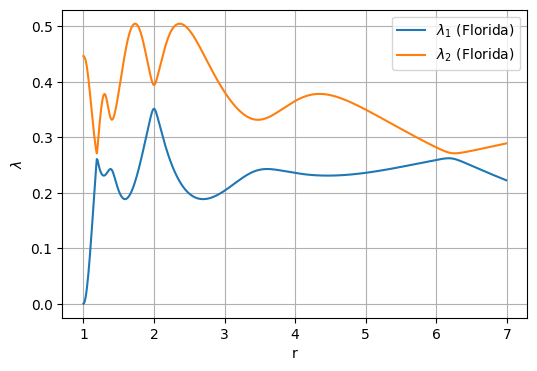

In [22]:
plt.figure(figsize=(6, 4))
#plt.plot(rValues, specGap_Cn, label=r"$C_n$")
plt.plot(rValues, eig1Gfull, label=rf"$\lambda_1$ (Florida)") 
plt.plot(rValues, eig2Gfull, label=rf"$\lambda_2$ (Florida)") #$\lambda_{2}-\lambda_{1}$
#plt.plot(rValues, specGap_Gsub, label=r"$G_{sub}$")
plt.xlabel(f"r")
plt.ylabel("$\lambda$")
#plt.title(r"$\lambda_{2}-\lambda_{1}$ for varying r (Florida)")
plt.legend()
plt.grid(True)
plt.legend()
plt.show()